# External replication — Utah Creighton Model cohort

Companion notebook for the external replication of *Null-Model Choice for Rule-Defined Pattern Counts in
Clustered Longitudinal Sequences: A Case Study of Jewish Halachic Menstrual Anticipation Rules* (D. Ross).

**Data**: Stanford, J. B., & Najmabadi, S. (2023). *Menstrual Cycles Length of Women in the USA and Canada,
1990–2013*. The Hive, University of Utah. https://doi.org/10.7278/S50d-4gxs-s4hj (CC BY-NC). Three Creighton
Model FertilityCare cohorts (CMFS 1990–96, TTP 2003–06, CEIBA 2009–13); women aged 18–40 with regular
bleeding and no known subfertility.

Counting rules are imported from the repository's `scripts/patterns.py` (the same code as the main analysis);
the analysis engine is `../scripts/analysis_engine.py`, verified to reproduce every cached Fehring result bit for
bit. Heavy Monte Carlo output is cached in `../results/` by `../scripts/run_external.py`; this notebook
re-derives all tables and figures from those replicates.

| Step | Script | Output |
|---|---|---|
| raw deposit → analysed sequences | `../scripts/prepare_utah.py` | `../data/sequences.csv`, `women.csv`, `preprocessing.json` |
| nulls, summary, sensitivity, validation, figures | `../scripts/run_external.py` | `../results/` |

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../../scripts')); sys.path.insert(0, os.path.abspath('../scripts'))
import numpy as np, pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from patterns import (count_all_loop, perm_within, perm_global, multinomial_iid, two_sided_p, holm_adjust,
                      mahalanobis_test, PATTERN_LABELS)
import analysis_engine as E
import external_figures as F

RES, DATA = '../results', '../data'
FIG = os.path.join(RES, 'figures')
pd.set_option('display.width', 160)

## 1. Source file and preprocessing

Rules fixed before any pattern was counted (see `../reports/utah_preprocessing_and_deviations.md`):
cycle length $L$ = recorded `cycle_length` (asserted equal to end − start + 1); $H = L + 1$; the 180 conception
cycles (no recorded length, all terminal) excluded; a woman's record split at every gap between consecutive
recorded cycles (never bridged); each woman contributes her longest run of ≥ 5 consecutive cycles; no
cycle-length cutoff.

In [2]:
raw = pd.read_csv(os.path.join(DATA, 'raw', 'CrMcyclelength_share.csv')); raw.columns = [c.lstrip('﻿') for c in raw.columns]
prep = json.load(open(os.path.join(DATA, 'preprocessing.json')))
print(f"raw deposit: {len(raw):,} rows, {raw.new_id.nunique()} women; recorded lengths {raw.cycle_length.min():.0f}-{raw.cycle_length.max():.0f}; "
      f"conception flags {raw.conception_cycle.value_counts().to_dict()}")
keys = ['conception_cycles_excluded', 'cycles_with_missing_conception_flag_kept', 'gap_breaks', 'gap_breaks_with_cycle_number_jump',
        'women_with_eligible_run', 'women_without_eligible_run', 'women_with_several_eligible_runs', 'n_women_analysed', 'n_cycles_analysed',
        'cycles_per_woman', 'L_min', 'L_max', 'n_cycles_L_below_18', 'n_cycles_L_above_54', 'age', 'cohort_era_counts']
display(pd.Series({k: prep[k] for k in keys}).to_frame('value'))
print('run-length histogram (all runs of consecutive recorded cycles):', prep['run_length_histogram'])

raw deposit: 3,324 rows, 581 women; recorded lengths 15-98; conception flags {'No': 3137, 'Yes': 180, 'Missing': 7}


,value
conception_cycles_excluded,180
cycles_with_missing_conception_flag_kept,7
gap_breaks,170
gap_breaks_with_cycle_number_jump,169
women_with_eligible_run,270
women_without_eligible_run,311
women_with_several_eligible_runs,7
n_women_analysed,270
n_cycles_analysed,2139
cycles_per_woman,"{'mean': 7.92, 'sd': 2.68, 'min': 5, 'max': 15}"


run-length histogram (all runs of consecutive recorded cycles): {'1': 179, '2': 113, '3': 89, '4': 74, '5': 70, '6': 45, '7': 38, '8': 21, '9': 27, '10': 20, '11': 23, '12': 17, '13': 4, '14': 10, '15': 2}


,utah
name,utah
n_women,270
n_cycles,2139
cycles_per_woman_mean,7.92
cycles_per_woman_sd,2.68
cycles_per_woman_min,5
cycles_per_woman_max,15
cycles_per_woman_median,7.0
L_mean,29.98
L_sd,6.16


Week anchors W (H with L a multiple of 7, within the observed range): [22, 29, 36, 43, 50, 57, 64, 71, 78, 85, 92, 99]


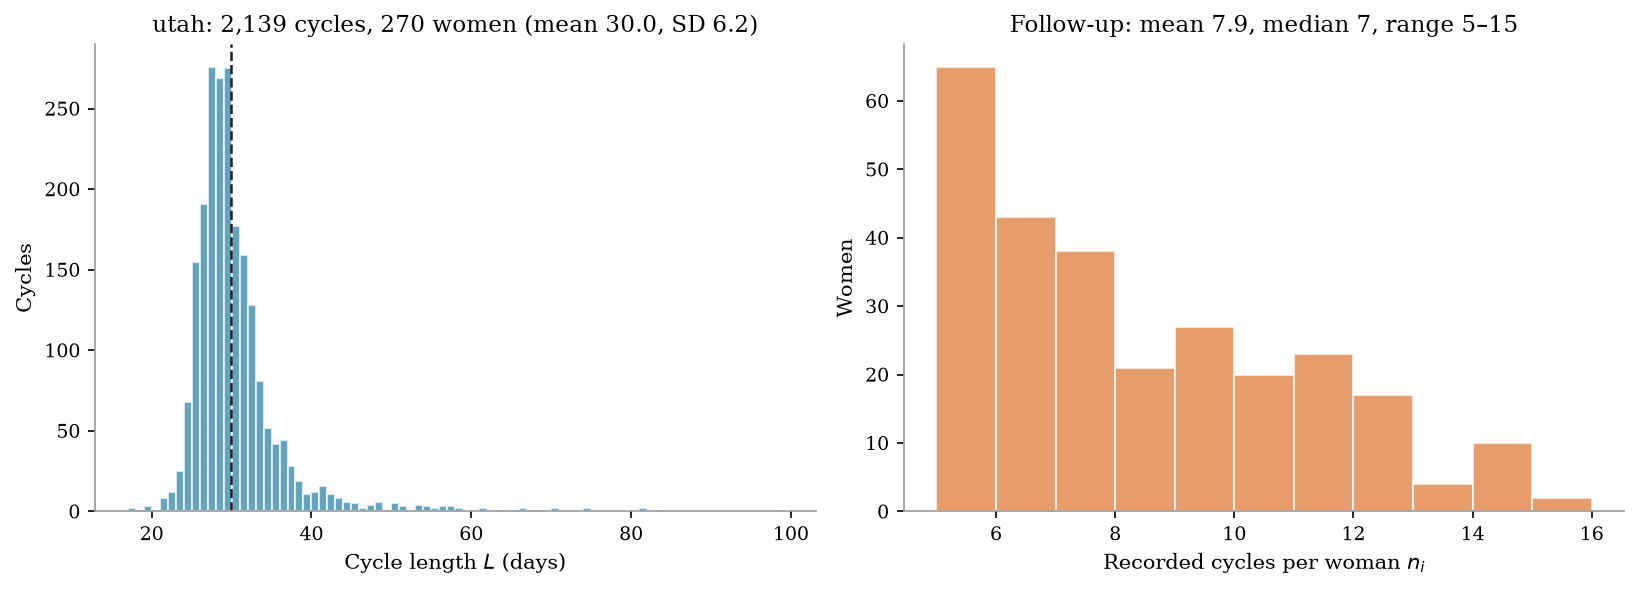

In [3]:
ds = E.Dataset.from_csv(os.path.join(DATA, 'sequences.csv'), 'utah')
women = pd.read_csv(os.path.join(DATA, 'women.csv'))
desc = ds.describe()
display(pd.Series(desc).to_frame('utah'))
print('Week anchors W (H with L a multiple of 7, within the observed range):', desc['weekly_anchors'])
from IPython.display import Image
F.fig_descriptives(ds, FIG); display(Image(os.path.join(FIG, 'figE1_descriptives.png')))

## 2. Counting rules and equivalence check

Same five rules as the main analysis (Haflaga ≥ 3 equal; Dilug constant non-zero first difference; Week two
consecutive **equal** values at a same-weekday anchor $H \in \{22, 29, 36, \ldots\}$; Week-Dilug two consecutive
values equal to 30; Dilug-in-Dilug constant non-zero second difference); distinct maximal runs, never across
women. The vectorised counter is checked against the reference loop implementation.

In [4]:
observed = ds.observed()
assert np.array_equal(observed, count_all_loop(ds.H, ds.bounds, ds.weekly))
rng = np.random.default_rng(0)
for _ in range(300):
    for x in (perm_global(ds.H, rng), perm_within(ds.H, ds.bounds, rng), multinomial_iid(ds.H, rng)):
        assert np.array_equal(ds.C.count(x), count_all_loop(x, ds.bounds, ds.weekly))
print('Vectorised and loop counters agree on the observed data and 900 null sequences (run_external.py checks 9,000).')
print('Observed counts:', dict(zip(PATTERN_LABELS, observed.tolist())))
pw = ds.C.count_by_woman(ds.H, ds.n_women); n_i = ds.n_i
print('Women establishing each pattern at least once:', dict(zip(PATTERN_LABELS, (pw > 0).sum(0).tolist())))

Vectorised and loop counters agree on the observed data and 900 null sequences (run_external.py checks 9,000).
Observed counts: {'Haflaga': 41, 'Dilug': 76, 'Week': 35, 'Week-Dilug': 40, 'Dilug-in-Dilug': 41}
Women establishing each pattern at least once: {'Haflaga': 38, 'Dilug': 66, 'Week': 33, 'Week-Dilug': 35, 'Dilug-in-Dilug': 39}


## 3. Null replicates

$H_G$ (global permutation), $H_{iid}$ (i.i.d. draws from the pooled empirical distribution) and $H_W$
(within-woman permutation without replacement), $B = 50{,}000$, seed 17, one shared RNG stream — identical
code and constants to the main analysis. Uncomment the last line to regenerate (≈ 1 min).

In [5]:
R = np.load(os.path.join(RES, 'null_replicates.npz'))
assert np.array_equal(R['observed'], observed) and int(R['n_cycles']) == ds.n_cycles
B = int(R['B']); obs = observed.astype(float)
arrs = {'H_G': R['perm'].astype(float), 'H_iid': R['multi'].astype(float), 'H_W': R['within'].astype(float)}
wbw = R['within_by_woman'].astype(np.int32)
print(f'Loaded B={B:,} replicates per null (seed {int(R["seed"])}).')
# R = E.run_nulls(ds, 50_000, 17)   # regenerate

Loaded B=50,000 replicates per null (seed 17).


## 4. Marginal tests
Two-sided Monte Carlo $p = \min\{1, 2\min((b^+ + 1)/(B+1), (b^- + 1)/(B+1))\}$; Holm across the five patterns
within each null.

,Null,Pattern,Obs,Mean,SD,z,p_two_sided,p_Holm,n_ge_obs,n_le_obs
0,H_G,Haflaga,41,12.420000,3.430000,8.330000,0.0000,0.0002,0,50000
1,H_G,Dilug,76,54.950000,6.990000,3.010000,0.0056,0.0210,139,49906
2,H_G,Week,35,27.090000,4.180000,1.890000,0.0834,0.0834,2083,48757
3,H_G,Week-Dilug,40,27.400000,4.170000,3.020000,0.0052,0.0210,130,49942
4,H_G,Dilug-in-Dilug,41,27.080000,5.040000,2.760000,0.0120,0.0241,300,49805
5,H_iid,Haflaga,41,12.560000,3.470000,8.200000,0.0000,0.0002,0,50000
6,H_iid,Dilug,76,54.840000,7.050000,3.000000,0.0052,0.0210,130,49911
7,H_iid,Week,35,27.170000,5.050000,1.550000,0.1559,0.1559,3897,47249
8,H_iid,Week-Dilug,40,27.520000,5.080000,2.460000,0.0251,0.0502,626,49623
9,H_iid,Dilug-in-Dilug,41,27.090000,5.090000,2.730000,0.0141,0.0422,351,49785


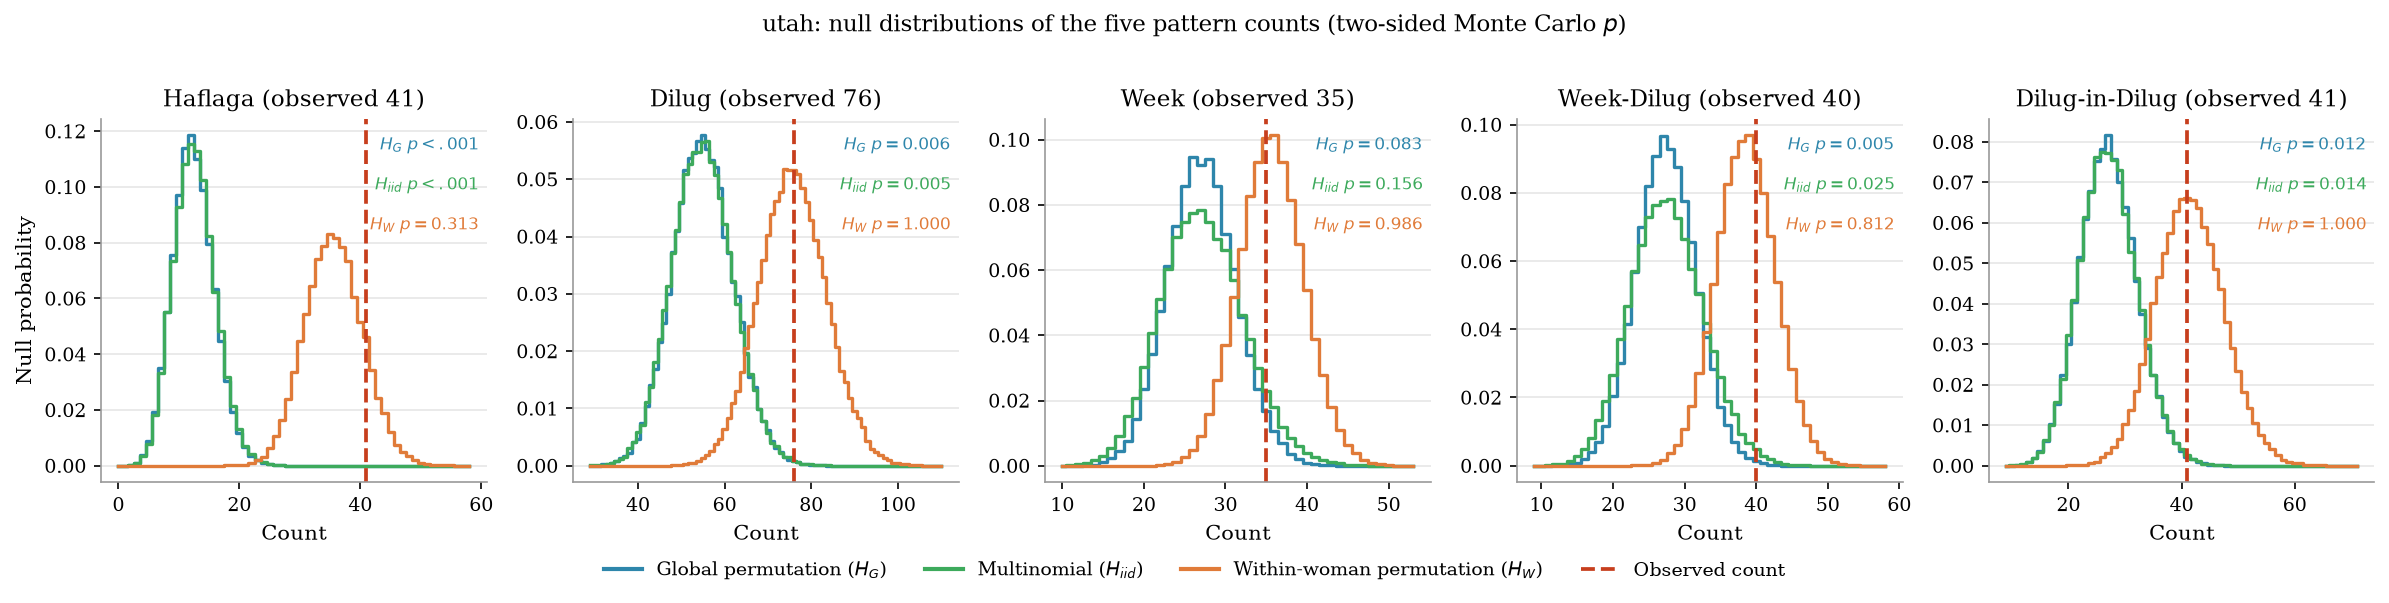

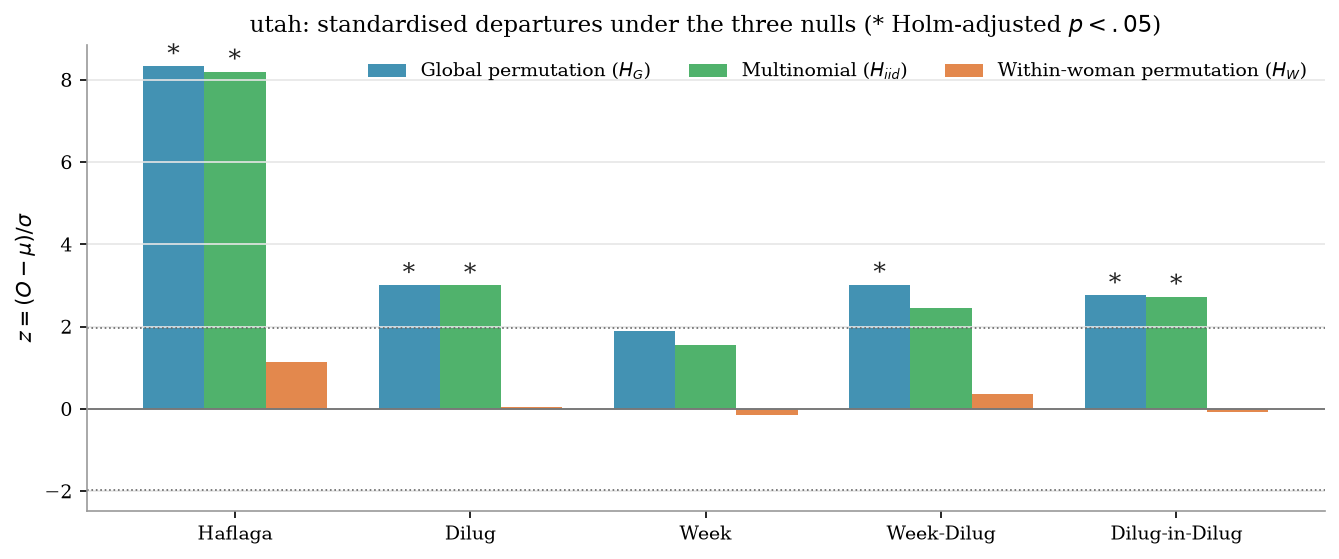

In [6]:
rows = []
for name, arr in arrs.items():
    mu, sd = arr.mean(0), arr.std(0, ddof=1)
    p = np.array([two_sided_p(arr[:, j], obs[j]) for j in range(5)]); adj = holm_adjust(p)
    for j, l in enumerate(PATTERN_LABELS):
        rows.append(dict(Null=name, Pattern=l, Obs=int(obs[j]), Mean=round(mu[j], 2), SD=round(sd[j], 2), z=round((obs[j]-mu[j])/sd[j], 2),
                         p_two_sided=round(p[j], 4), p_Holm=round(adj[j], 4), n_ge_obs=int((arr[:, j] >= obs[j]).sum()), n_le_obs=int((arr[:, j] <= obs[j]).sum())))
marg = pd.DataFrame(rows)
display(marg.style.format({'p_two_sided': '{:.4f}', 'p_Holm': '{:.4f}'}).set_caption('Utah: marginal results'))
summ = json.load(open(os.path.join(RES, 'summary.json')))
F.fig_null_pmfs(summ, R, FIG); display(Image(os.path.join(FIG, 'figE2_null_distributions.png')))
F.fig_zscores(summ, FIG); display(Image(os.path.join(FIG, 'figE3_zscores.png')))

## 5. Joint five-pattern Mahalanobis test (primary), split-batch check, exploratory three-pattern subspace

,D_M,p,n_exceed,D_M_split,p_split,D_M_3pattern,p_3pattern,cond,max_abs_corr
Null,,,,,,,,,
H_G,9.991,0.0000,0,10.026,0.0000,9.100,0.0000,4.52,0.112
H_iid,9.529,0.0000,0,9.518,0.0000,8.809,0.0000,4.45,0.136
H_W,1.200,0.9211,46057,1.195,0.9221,1.172,0.7145,3.97,0.115


H_W null covariance:


,Haflaga,Dilug,Week,Week-Dilug,Dilug-in-Dilug
Haflaga,22.84,-2.65,1.02,0.71,-3.27
Dilug,-2.65,60.00,-2.78,-2.30,-2.84
Week,1.02,-2.78,15.74,0.50,1.22
Week-Dilug,0.71,-2.30,0.50,16.81,0.91
Dilug-in-Dilug,-3.27,-2.84,1.22,0.91,35.46


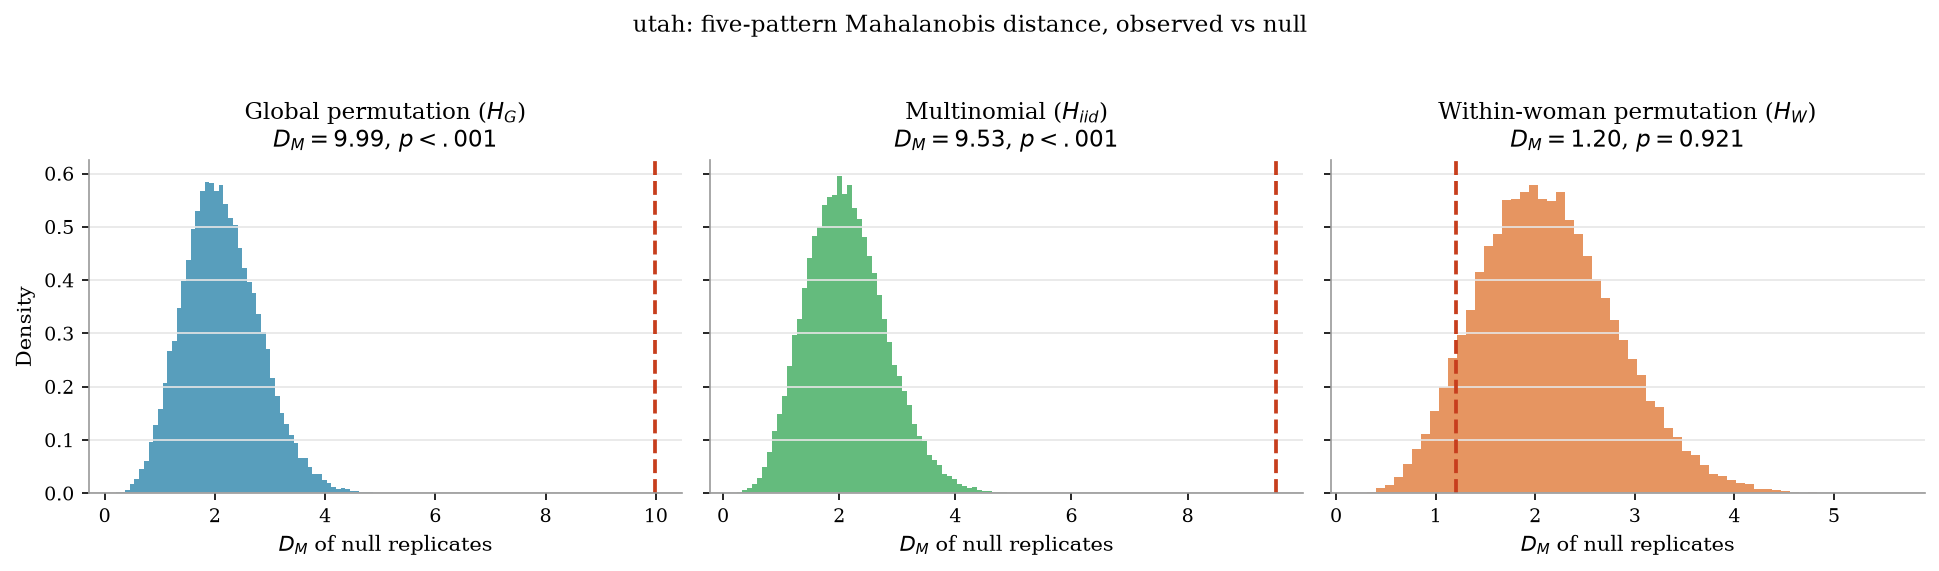

In [7]:
joint = []
for name, arr in arrs.items():
    DM, p, dm_null, Sig = mahalanobis_test(arr, obs)
    DMs, ps, _, _ = mahalanobis_test(arr[B//2:], obs, ref=arr[:B//2])
    DM3, p3, _, _ = mahalanobis_test(arr[:, [0, 3, 4]], obs[[0, 3, 4]])
    corr = np.corrcoef(arr.T); np.fill_diagonal(corr, 0)
    joint.append(dict(Null=name, D_M=round(DM, 3), p=round(p, 4), n_exceed=int((dm_null >= DM).sum()), D_M_split=round(DMs, 3), p_split=round(ps, 4),
                      D_M_3pattern=round(DM3, 3), p_3pattern=round(p3, 4), cond=round(np.linalg.cond(Sig), 2), max_abs_corr=round(np.abs(corr).max(), 3)))
display(pd.DataFrame(joint).set_index('Null'))
print('H_W null covariance:'); display(pd.DataFrame(np.cov(arrs['H_W'].T), index=PATTERN_LABELS, columns=PATTERN_LABELS).round(2))
F.fig_dm(summ, R, FIG); display(Image(os.path.join(FIG, 'figE4_dm_nulldist.png')))

## 6. Leave-one-woman-out ($H_W$) and follow-up influence
Exact: each woman's contribution is subtracted from the observed vector and from every replicate (additive
per-woman counts), so no re-simulation is needed.

In [8]:
loo, loo_p, loo_pm = E.leave_one_out(obs, arrs['H_W'], wbw, pw)
print({k: v for k, v in loo.items()})
q80 = np.quantile(n_i, .8); long = n_i >= q80
print(f'top follow-up quintile (n_i >= {q80:.0f}): {long.sum()} women hold {n_i[long].sum()/n_i.sum():.1%} of cycles and '
      f'{dict(zip(PATTERN_LABELS, np.round(pw[long].sum(0)/pw.sum(0), 2)))} of events')
print('Spearman(n_i, events per woman):', dict(zip(PATTERN_LABELS, [round(stats.spearmanr(n_i, pw[:, j])[0], 2) for j in range(5)])))

{'joint_p_min': 0.8614, 'joint_p_max': 0.9735, 'n_joint_p_below_05': 0, 'marginal_p_min': [0.248, 0.8409, 0.7918, 0.6499, 0.7952], 'marginal_p_max': [0.4665, 1.0, 1.0, 0.9971, 1.0], 'n_marg_below_05': [0, 0, 0, 0, 0], 'most_influential_woman_index': 35}
top follow-up quintile (n_i >= 11): 56 women hold 31.7% of cycles and {'Haflaga': np.float64(0.56), 'Dilug': np.float64(0.33), 'Week': np.float64(0.43), 'Week-Dilug': np.float64(0.4), 'Dilug-in-Dilug': np.float64(0.32)} of events
Spearman(n_i, events per woman): {'Haflaga': np.float64(0.3), 'Dilug': np.float64(0.18), 'Week': np.float64(0.16), 'Week-Dilug': np.float64(0.17), 'Dilug-in-Dilug': np.float64(0.18)}


## 7. Sensitivity analyses
* **Harmonised support** 18 ≤ L ≤ 54 (the observed range of the Marquette data; a support restriction, not the
  Marquette inclusion criterion): out-of-range cycles removed, sequences split at those points, blocks of ≥ 5 kept.
* **Truncation** to each woman's first 12 cycles (from the validation run, Part C).

In [9]:
sens = json.load(open(os.path.join(RES, 'sensitivity_L18-54.json')))
print('18-54:', sens['info']); print('observed counts', sens['observed'])
display(pd.DataFrame({m: dict(D_M=sens[m]['DM'], p=sens[m]['p_DM'], D_M_split=sens[m]['DM_split'], p_split=sens[m]['p_DM_split'],
                               p_two_sided=sens[m]['p_two'], Holm=sens[m]['holm']) for m in ['G', 'iid', 'W']}).T)
V = np.load(os.path.join(RES, 'sim_validation.npz'), allow_pickle=True)
c = V['part_c'][0]
print(f"first-12 truncation: {c['n_cycles']} cycles, {c['n_women']} women; obs {c['obs'].astype(int).tolist()}; H_W mean {np.round(c['mu'],2).tolist()}; "
      f"z {np.round(c['z'],2).tolist()}; p {np.round(c['p'],3).tolist()}; D_M {c['DM']:.2f} p {c['pj']:.3f}")

18-54: {'lo': 18, 'hi': 54, 'min_cycles': 5, 'cycles_removed': 28, 'women_kept': 258, 'women_split_into_several_blocks': 0, 'n_blocks': 258, 'n_cycles': 2050}
observed counts [41, 76, 35, 40, 41]


,D_M,p,D_M_split,p_split,p_two_sided,Holm
G,9.267,0.0,9.251,0.0,"[0.0, 0.0136, 0.1153, 0.0089, 0.0243]","[0.0002, 0.0407, 0.1153, 0.0357, 0.0486]"
iid,8.846,0.0,8.827,0.0,"[0.0, 0.0118, 0.2049, 0.0362, 0.028]","[0.0002, 0.047, 0.2049, 0.0841, 0.0841]"
W,1.151,0.9333,1.159,0.9344,"[0.3158, 1.0, 1.0, 0.8586, 1.0]","[1.0, 1.0, 1.0, 1.0, 1.0]"


first-12 truncation: 2109 cycles, 270 women; obs [40, 75, 34, 36, 41]; H_W mean [34.21, 73.9, 34.43, 37.08, 40.34]; z [1.25, 0.14, -0.11, -0.27, 0.11]; p [0.257, 0.927, 1.0, 0.89, 0.967]; D_M 1.34 p 0.878


## 8. Simulation validation (same sizes as the paper)
Part A: size of every procedure (10,000 fresh datasets per null vs an independent batch of 20,000 replicates).
Part B: $H_W$ power against AR(1) and persistence alternatives (400 datasets × 2,000 permutations per scenario).

,marg_Haflaga,marg_Dilug,marg_Week,marg_Week-Dilug,marg_Dilug-in-Dilug,Holm_FWER,joint_plugin,joint_split,joint_plugin_01,joint_split_01
null,,,,,,,,,,
H_G,0.039,0.042,0.030,0.032,0.046,0.039,0.051,0.051,0.0097,0.0083
H_iid,0.028,0.039,0.038,0.036,0.048,0.038,0.052,0.046,0.0086,0.0086
H_W,0.045,0.042,0.044,0.036,0.035,0.034,0.049,0.051,0.0112,0.0112


,Haflaga,Dilug,Week,Week-Dilug,Dilug-in-Dilug,Holm_any,joint
alternative,,,,,,,
ar1 0.0,0.030,0.048,0.035,0.032,0.035,0.030,0.045
ar1 0.25,0.135,0.278,0.110,0.060,0.132,0.222,0.442
ar1 0.5,0.682,0.818,0.358,0.200,0.465,0.878,0.992
ar1 0.75,1.000,0.992,0.778,0.595,0.585,1.000,1.000
persist 0.0,0.045,0.025,0.030,0.058,0.035,0.028,0.058
persist 0.1,0.960,0.180,0.540,0.360,0.058,0.938,0.970
persist 0.2,1.000,0.422,0.942,0.782,0.070,1.000,1.000
persist 0.3,1.000,0.718,0.988,0.908,0.362,1.000,1.000


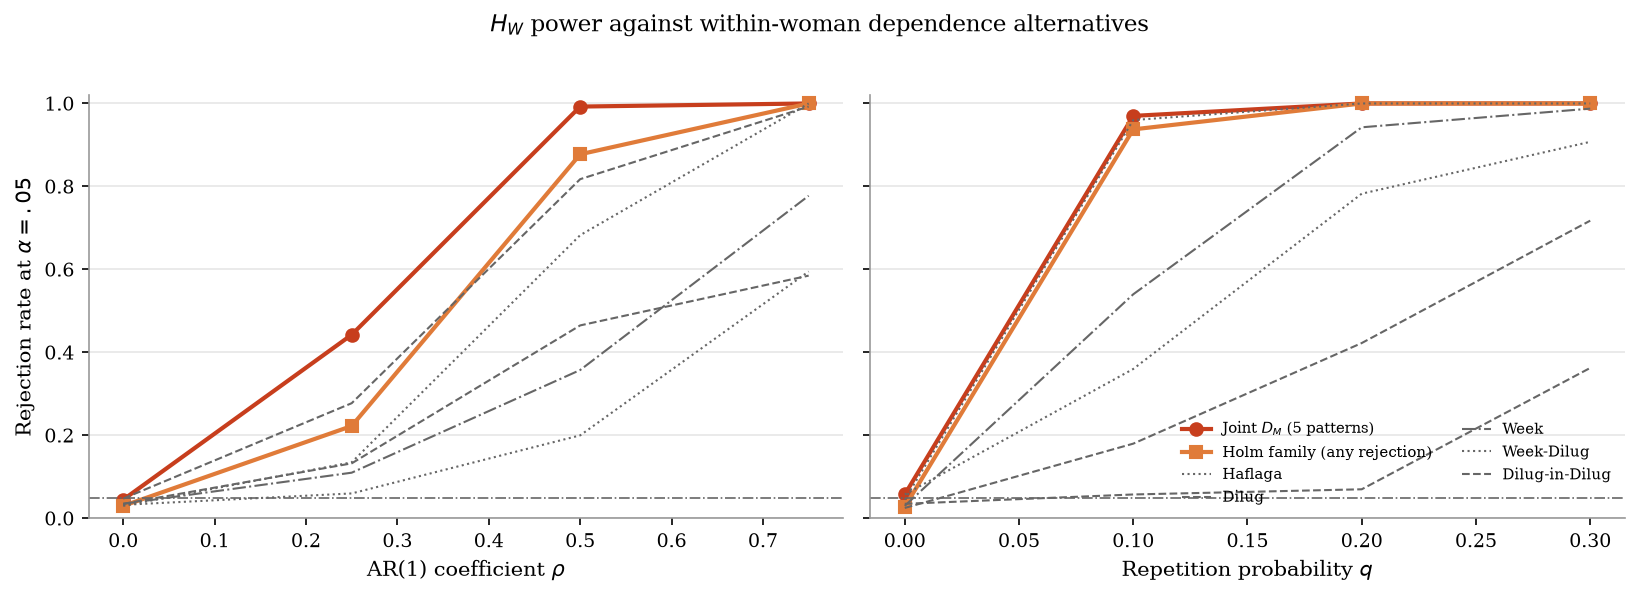

In [10]:
A = list(V['part_a']); Bp = list(V['part_b'])
display(pd.DataFrame([dict(null='H_'+r['null'], **{f'marg_{l}': round(r['marg_rate'][j], 3) for j, l in enumerate(PATTERN_LABELS)},
                           Holm_FWER=round(r['holm_fwer'], 3), joint_plugin=round(r['joint_plug_05'], 3), joint_split=round(r['joint_split_05'], 3),
                           joint_plugin_01=round(r['joint_plug_01'], 4), joint_split_01=round(r['joint_split_01'], 4)) for r in A]).set_index('null'))
display(pd.DataFrame([dict(alternative=f"{r['family']} {r['level']}", **{l: round(r['marg_power'][j], 3) for j, l in enumerate(PATTERN_LABELS)},
                           Holm_any=round(r['holm_power'], 3), joint=round(r['joint_power'], 3)) for r in Bp]).set_index('alternative'))
val = dict(part_a=A, part_b=Bp, part_c=c)
F.fig_power(val, FIG); display(Image(os.path.join(FIG, 'figE6_power.png')))

## 9. Exploratory pairwise analyses (Supporting-Information type)
Per-woman rates, Spearman, two-sided permutation $p$ (50,000, seed 17), Holm over the ten pairs; binary
ever/never and follow-up-stratified robustness. Between-woman associations only.

In [11]:
display(pd.DataFrame(summ['pairwise_rate_spearman']).set_index('pair'))
display(pd.DataFrame(summ['pairwise_binary']).set_index('pair').head(4))
print(summ['pairwise_followup_robustness'])
print('SD comparison (descriptive; expected by construction):', summ['sd_comparison'])

,r,p_perm,p_holm
pair,,,
Haflaga x Week,0.27,0.0001,0.001
Haflaga x Dilug-in-Dilug,-0.09,0.1445,1.000
Week-Dilug x Dilug-in-Dilug,0.09,0.1716,1.000
Haflaga x Week-Dilug,0.09,0.1783,1.000
Dilug x Dilug-in-Dilug,0.07,0.2228,1.000
Haflaga x Dilug,-0.07,0.2434,1.000
Dilug x Week,-0.05,0.3680,1.000
Dilug x Week-Dilug,0.01,0.8859,1.000
Week x Week-Dilug,-0.01,0.9110,1.000


,chi2,p_perm,p_fisher,p_holm
pair,,,,
Haflaga x Week,19.93,0.0001,0.0001,0.001
Haflaga x Week-Dilug,2.57,0.1198,0.1199,1.000
Week-Dilug x Dilug-in-Dilug,2.30,0.1943,0.1296,1.000
Dilug x Dilug-in-Dilug,1.95,0.2257,0.1642,1.000


{'spearman_n_vs_rate': [0.28, 0.1, 0.13, 0.14, 0.16], 'strata_sizes': [0, 108, 38, 68, 56], 'pairs': [{'pair': 'Haflaga x Dilug-in-Dilug', 'r': -0.086, 'partial_r_given_n': -0.136, 'p_perm_stratified_by_followup_quintile': 0.2097}, {'pair': 'Haflaga x Week-Dilug', 'r': 0.086, 'partial_r_given_n': 0.049, 'p_perm_stratified_by_followup_quintile': 0.2134}]}
SD comparison (descriptive; expected by construction): {'n_haf': 38, 'mean_sd_haf': 1.89, 'sd_between_haf': 1.37, 'n_none': 124, 'mean_sd_none': 4.61, 'sd_between_none': 4.47, 'U': 1010.5, 'p_U': 1.058182464893048e-07, 't': -5.91, 'df': 160.0, 'p_t': 1.9597006829550054e-08, 'ci': [-3.62, -1.81], 'cohen_d': -0.68}


## 10. Side-by-side with the Marquette (Fehring) analysis and decomposition of the global $z$
$z_G = (\mu_W - \mu_G)/\sigma_G + (O - \mu_W)/\sigma_G$: a between-woman heterogeneity gap plus the departure of
the observed count from its own within-woman expectation.

z_Haflaga  z_Dilug  z_Week  z_Week-Dilug  z_Dilug-in-Dilug    D_M       p
Null  dataset                                                                           
H_G   Fehring       4.50     1.84    1.24          0.54             -0.03  5.080  0.0001
      Utah          8.33     3.01    1.89          3.02              2.76  9.991  0.0000
H_iid Fehring       4.39     1.84    0.98          0.42             -0.06  4.867  0.0004
      Utah          8.20     3.00    1.55          2.46              2.73  9.529  0.0000
H_W   Fehring      -1.25    -0.82   -0.46         -0.90             -2.07  2.933  0.1257
      Utah          1.13     0.04   -0.15          0.35             -0.08  1.200  0.9211

Fehring  heterogeneity gap [6.28 2.76 1.69 1.43 2.39]  within-woman residual [-1.79 -0.92 -0.45 -0.9  -2.42]  z_G [ 4.49  1.84  1.24  0.54 -0.03]
Utah     heterogeneity gap [6.76 2.97 2.04 2.68 2.86]  within-woman residual [ 1.57  0.04 -0.15  0.35 -0.1 ]  z_G [8.33 3.01 1.89 3.02 2.76]


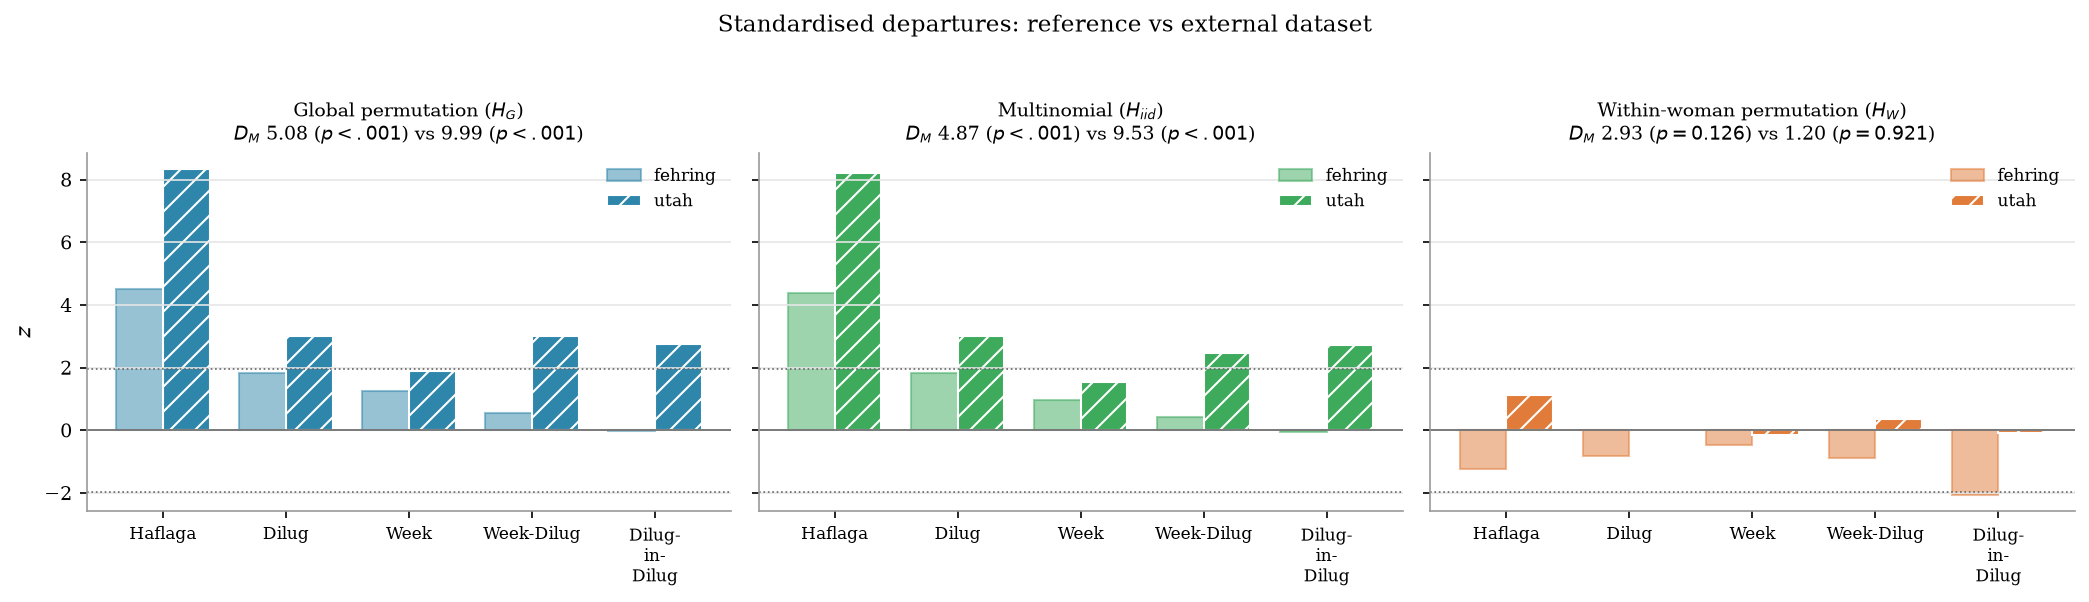

# utah vs Fehring — side-by-side

## Dataset characteristics

| | Fehring | utah |
|---|---|---|
| women | 118 | 270 |
| cycles | 1554 | 2139 |
| cycles/woman mean | 13.17 | 7.92 |
| cycles/woman SD | 6.06 | 2.68 |
| cycles/woman min | 5 | 5 |
| cycles/woman max | 45 | 15 |
| L mean | 29.27 | 29.98 |
| L SD | 3.86 | 6.16 |
| L median | 28.5 | 29.0 |
| L min | 18 | 17 |
| L max | 54 | 98 |
| share L >= 35 | 0.096 | 0.12 |
| Week anchors (H) | [22, 29, 36, 43, 50] | [22, 29, 36, 43, 50, 57, 64, 71, 78, 85, 92, 99] |

## Observed five-pattern counts

| Pattern | Fehring | utah |
|---|---|---|
| Haflaga | 26 | 41 |
| Dilug | 61 | 76 |
| Week | 32 | 35 |
| Week-Dilug | 18 | 40 |
| Dilug-in-Dilug | 27 | 41 |

## Marginal tests under H_G global permutation

| Pattern | Fehring μ (σ) | z | p | Holm | utah μ (σ) | z | p | Holm |
|---|---|---|---|---|---|---|---|---|
| Haflaga | 11.31 (3.27) | +4.50 | 0.0002 | 0.001 | 12.42 (3.43) | +8.33 | 0.0000 | 0.000 |
| Dilug | 48.92 (6.57) | +1.84 | 0.0850 | 0.340 | 54.95 (6.99) | +3.01 | 0.0056 | 0.021 |
| Week | 27.02 (4.01) | +1.24 | 0.2647 | 0.794 | 27.09 (4.18) | +1.89 | 0.0834 | 0.083 |
| Week-Dilug | 16.25 (3.25) | +0.54 | 0.6882 | 1.000 | 27.4 (4.17) | +3.02 | 0.0052 | 0.021 |
| Dilug-in-Dilug | 27.17 (5.0) | -0.03 | 1.0000 | 1.000 | 27.08 (5.04) | +2.76 | 0.0120 | 0.024 |

## Marginal tests under H_iid multinomial

| Pattern | Fehring μ (σ) | z | p | Holm | utah μ (σ) | z | p | Holm |
|---|---|---|---|---|---|---|---|---|
| Haflaga | 11.48 (3.31) | +4.39 | 0.0003 | 0.001 | 12.56 (3.47) | +8.20 | 0.0000 | 0.000 |
| Dilug | 48.86 (6.59) | +1.84 | 0.0820 | 0.328 | 54.84 (7.05) | +3.00 | 0.0052 | 0.021 |
| Week | 27.09 (5.0) | +0.98 | 0.3732 | 1.000 | 27.17 (5.05) | +1.55 | 0.1559 | 0.156 |
| Week-Dilug | 16.35 (3.94) | +0.42 | 0.7428 | 1.000 | 27.52 (5.08) | +2.46 | 0.0251 | 0.050 |
| Dilug-in-Dilug | 27.3 (5.07) | -0.06 | 1.0000 | 1.000 | 27.09 (5.09) | +2.73 | 0.0141 | 0.042 |

## Marginal tests under H_W within-woman permutation

| Pattern | Fehring μ (σ) | z | p | Holm | utah μ (σ) | z | p | Holm |
|---|---|---|---|---|---|---|---|---|
| Haflaga | 31.84 (4.68) | -1.25 | 0.2536 | 1.000 | 35.6 (4.78) | +1.13 | 0.3128 | 1.000 |
| Dilug | 67.04 (7.38) | -0.82 | 0.4596 | 1.000 | 75.71 (7.75) | +0.04 | 1.0000 | 1.000 |
| Week | 33.79 (3.88) | -0.46 | 0.7489 | 1.000 | 35.61 (3.97) | -0.15 | 0.9857 | 1.000 |
| Week-Dilug | 20.91 (3.22) | -0.90 | 0.4597 | 1.000 | 38.56 (4.1) | +0.35 | 0.8123 | 1.000 |
| Dilug-in-Dilug | 39.12 (5.84) | -2.07 | 0.0383 | 0.192 | 41.48 (5.95) | -0.08 | 1.0000 | 1.000 |

## Joint tests

| Null | Statistic | Fehring | utah |
|---|---|---|---|
| H_G | 5-pattern D_M | 5.08 | 9.991 |
| H_G | 5-pattern p | 0.0001 | 0.0 |
| H_G | split-batch D_M | 5.073 | 10.026 |
| H_G | split-batch p | 0.0002 | 0.0 |
| H_G | 3-pattern D_M (exploratory) | 4.501 | 9.1 |
| H_G | 3-pattern p | 0.0002 | 0.0 |
| H_G | covariance condition number | 4.62 | 4.52 |
| H_iid | 5-pattern D_M | 4.867 | 9.529 |
| H_iid | 5-pattern p | 0.0004 | 0.0 |
| H_iid | split-batch D_M | 4.87 | 9.518 |
| H_iid | split-batch p | 0.0003 | 0.0 |
| H_iid | 3-pattern D_M (exploratory) | 4.389 | 8.809 |
| H_iid | 3-pattern p | 0.0005 | 0.0 |
| H_iid | covariance condition number | 4.36 | 4.45 |
| H_W | 5-pattern D_M | 2.933 | 1.2 |
| H_W | 5-pattern p | 0.1257 | 0.9211 |
| H_W | split-batch D_M | 2.954 | 1.195 |
| H_W | split-batch p | 0.1186 | 0.9221 |
| H_W | 3-pattern D_M (exploratory) | 2.679 | 1.172 |
| H_W | 3-pattern p | 0.0666 | 0.7145 |
| H_W | covariance condition number | 5.41 | 3.97 |

## Leave-one-woman-out (H_W)

| | Fehring | utah |
|---|---|---|
| joint p range | 0.0546–0.2244 | 0.8614–0.9735 |
| # LOO joint p < .05 | 0 | 0 |
| marginal p min | [0.1206, 0.3427, 0.5338, 0.3073, 0.0142] | [0.248, 0.8409, 0.7918, 0.6499, 0.7952] |
| marginal p max | [0.3867, 0.6004, 0.9298, 0.689, 0.073] | [0.4665, 1.0, 1.0, 0.9971, 1.0] |

## Harmonised-support sensitivity (18 <= L <= 54), external dataset

blocks 258 from 258 women, 2050 cycles; 28 cycles removed; 0 women split at a gap.

| Null | 5-pattern D_M | p | split p | marginal two-sided p (Haf, Dil, Wk, W-D, DiD) | Holm |
|---|---|---|---|---|---|
| H_G | 9.267 | 0.0 | 0.0 | [0.0, 0.0136, 0.1153, 0.0089, 0.0243] | [0.0002, 0.0407, 0.1153, 0.0357, 0.0486] |
| H_iid | 8.846 | 0.0 | 0.0 | [0.0, 0.0118, 0.2049, 0.0362, 0.028] | [0.0002, 0.047, 0.2049, 0.0841, 0.0841] |
| H_W | 1.151 | 0.9333 | 0.9344 | [0.3158, 1.0, 1.0, 0.8586, 1.0] | [1.0, 1.0, 1.0, 1.0, 1.0] |

## Simulation validation

| | Fehring | utah |
|---|---|---|
| size H_G: marginal | [0.029, 0.047, 0.034, 0.031, 0.046] | [0.039, 0.042, 0.03, 0.032, 0.046] |
| size H_G: Holm / joint plug-in / split | 0.033 / 0.048 / 0.052 | 0.039 / 0.051 / 0.051 |
| size H_iid: marginal | [0.048, 0.038, 0.04, 0.038, 0.046] | [0.028, 0.039, 0.038, 0.036, 0.048] |
| size H_iid: Holm / joint plug-in / split | 0.032 / 0.049 / 0.047 | 0.038 / 0.052 / 0.046 |
| size H_W: marginal | [0.043, 0.041, 0.043, 0.042, 0.04] | [0.045, 0.042, 0.044, 0.036, 0.035] |
| size H_W: Holm / joint plug-in / split | 0.037 / 0.053 / 0.053 | 0.034 / 0.049 / 0.051 |
| power ar1 0.0: Holm / joint | 0.028 / 0.062 | 0.030 / 0.045 |
| power ar1 0.25: Holm / joint | 0.260 / 0.507 | 0.223 / 0.443 |
| power ar1 0.5: Holm / joint | 0.892 / 0.995 | 0.877 / 0.993 |
| power ar1 0.75: Holm / joint | 1.000 / 1.000 | 1.000 / 1.000 |
| power persist 0.0: Holm / joint | 0.052 / 0.062 | 0.028 / 0.058 |
| power persist 0.1: Holm / joint | 0.935 / 0.983 | 0.938 / 0.970 |
| power persist 0.2: Holm / joint | 1.000 / 1.000 | 1.000 / 1.000 |
| power persist 0.3: Holm / joint | 1.000 / 1.000 | 1.000 / 1.000 |
| first-12 truncation: cycles, D_M, p | 1289, 2.49, 0.289 | 2109, 1.34, 0.878 |

## Exploratory pairwise (per-woman rates, Spearman, permutation p, Holm over 10 pairs)

| Pair | Fehring r / p / Holm | utah r / p / Holm |
|---|---|---|
| Haflaga x Week | 0.1 / 0.277 / 1.0 | 0.27 / 0.0001 / 0.001 |
| Haflaga x Dilug-in-Dilug | 0.27 / 0.0038 / 0.038 | -0.09 / 0.1445 / 1.0 |
| Week-Dilug x Dilug-in-Dilug | 0.07 / 0.4802 / 1.0 | 0.09 / 0.1716 / 1.0 |
| Haflaga x Week-Dilug | 0.23 / 0.0113 / 0.102 | 0.09 / 0.1783 / 1.0 |
| Dilug x Dilug-in-Dilug | -0.02 / 0.819 / 1.0 | 0.07 / 0.2228 / 1.0 |
| Haflaga x Dilug | 0.04 / 0.668 / 1.0 | -0.07 / 0.2434 / 1.0 |
| Dilug x Week | 0.09 / 0.3374 / 1.0 | -0.05 / 0.368 / 1.0 |
| Dilug x Week-Dilug | -0.12 / 0.2059 / 1.0 | 0.01 / 0.8859 / 1.0 |
| Week x Week-Dilug | 0.06 / 0.4755 / 1.0 | -0.01 / 0.911 / 1.0 |
| Week x Dilug-in-Dilug | 0.09 / 0.3262 / 1.0 | -0.0 / 0.9802 / 1.0 |


In [12]:
ref = json.load(open('../../results/summary.json')); ref.setdefault('dataset', 'fehring')
ref.setdefault('description', E.Dataset.from_csv('../../data/FilteredData.csv', 'fehring').describe())
tab = []
for m in ['G', 'iid', 'W']:
    for lab, S in [('Fehring', ref), ('Utah', summ)]:
        tab.append(dict(Null='H_'+m, dataset=lab, **{f'z_{l}': S[m]['z'][j] for j, l in enumerate(PATTERN_LABELS)}, D_M=S[m]['DM'], p=S[m]['p_DM']))
display(pd.DataFrame(tab).set_index(['Null', 'dataset']))
for lab, S in [('Fehring', ref), ('Utah', summ)]:
    o = np.array(S['observed'], float); mG, sG, mW = (np.array(S['G'][k]) for k in ('mean', 'sd', 'mean')); mW = np.array(S['W']['mean'])
    print(f"{lab:8s} heterogeneity gap {np.round((mW-mG)/sG, 2)}  within-woman residual {np.round((o-mW)/sG, 2)}  z_G {np.round((o-mG)/sG, 2)}")
F.fig_comparison(ref, summ, FIG); display(Image(os.path.join(FIG, 'figE5_comparison_z.png')))
display(Markdown(open(os.path.join(RES, 'comparison.md')).read()))

## 10b. Regularity strata and per-woman concentration under $H_W$ (main article SI, Section S6)
Same checks as for the Marquette data (`scripts/per_woman_hw.py` in the repository root): $H_W$ tests within
terciles/halves of within-woman SD, and whether the women producing the most events are those the null expects to.

In [13]:
from per_woman_hw import run as per_woman_checks
pw_res = per_woman_checks(os.path.join(DATA, 'sequences.csv'), os.path.join(RES, 'null_replicates.npz'))

ordering check: Spearman(per-woman H_W mean total, n_i) = 0.641 (expect strongly positive)
=== A. H_W by within-woman regularity (SD of intervals)


most regular tercile             n= 90 women,  741 cycles, SD 0.52-1.77
   obs [25, 39, 21, 22, 23]  mu [22.53, 36.53, 19.57, 17.98, 20.7]  z [0.68, 0.47, 0.51, 1.59, 0.56]  p [0.5776, 0.6999, 0.731, 0.1604, 0.6465]  Holm [1.0, 1.0, 1.0, 0.802, 1.0]  D_M 1.998 p 0.5527 cond 4.6
middle tercile                   n= 90 women,  708 cycles, SD 1.78-2.94
   obs [12, 23, 8, 10, 12]  mu [9.41, 25.93, 10.11, 13.27, 13.24]  z [1.0, -0.65, -0.92, -1.33, -0.36]  p [0.4098, 0.6067, 0.4896, 0.2558, 0.855]  Holm [1.0, 1.0, 1.0, 1.0, 1.0]  D_M 2.101 p 0.4935 cond 4.0
least regular tercile            n= 90 women,  690 cycles, SD 2.98-26.87
   obs [4, 14, 6, 8, 6]  mu [3.66, 13.24, 5.92, 7.3, 7.53]  z [0.2, 0.23, 0.05, 0.34, -0.59]  p [1.0, 0.9066, 1.0, 0.906, 0.7251]  Holm [1.0, 1.0, 1.0, 1.0, 1.0]  D_M 0.733 p 0.9908 cond 4.4
below-median SD (more regular)   n=135 women, 1110 cycles, SD 0.52-2.16
   obs [33, 48, 26, 27, 32]  mu [29.17, 50.97, 25.49, 25.26, 28.37]  z [0.92, -0.47, 0.15, 0.58, 0.75]  p 

Spearman(observed total per woman, H_W expected total): rho = 0.702 (p = 1.80e-41)
  observed total vs regularity (-SD): rho = 0.419; vs n_i: rho = 0.414
  top-5 by observed vs top-5 by expected: overlap 3/5
  top-10 by observed vs top-10 by expected: overlap 4/10
  top-20 by observed vs top-20 by expected: overlap 8/20
  women with per-woman two-sided p < .05: 1 of 270 (null expectation ~13.5); min Holm 1.000, min BH q 1.000
  per-woman z: mean 0.016, SD 0.932, max 3.05, min -2.19; women with z > 2: 8, z < -2: 1
  top-10 women by observed events: obs total | H_W mean (sd) | z | p | n_i | SD | rank of expected
   #263:  5 [1, 0, 2, 2, 0] |  3.98 (1.51) | z +0.67 | p 0.735 | n 15 | SD 1.15 | exp-rank 1
   #198:  5 [0, 3, 1, 0, 1] |  3.41 (1.23) | z +1.29 | p 0.366 | n 14 | SD 1.20 | exp-rank 3
   # 81:  5 [2, 1, 1, 1, 0] |  3.76 (1.29) | z +0.96 | p 0.572 | n 12 | SD 0.95 | exp-rank 2
   #161:  4 [1, 0, 0, 2, 1] |  2.95 (0.88) | z +1.19 | p 0.524 | n 11 | SD 1.21 | exp-rank 6
   #205:  

  share of events held by top-6 women: observed 0.107; H_W null mean 0.110 (SD 0.010); two-sided p = 0.753
  share of events held by top-12 women: observed 0.185; H_W null mean 0.192 (SD 0.013); two-sided p = 0.558
  share of events held by top-24 women: observed 0.313; H_W null mean 0.326 (SD 0.018); two-sided p = 0.487


  Gini of per-woman event totals: observed 0.595; null mean 0.600 (SD 0.021); two-sided p = 0.796
  women with no event of any type: observed 124; null mean 125.3 (SD 6.6); two-sided p = 0.901


## 11. Provenance

In [14]:
prov = json.load(open(os.path.join(RES, 'provenance.json')))
display(pd.Series({k: v for k, v in prov.items() if k != 'preprocessing'}).to_frame('value'))

,value
dataset,utah
sequences_csv,external_replication/data/sequences.csv
sequences_sha256,08dddb0c04c6a107b95eefc6ef081fabedfe2e22bd8c98...
B,50000
seed,17
pairwise_B,50000
validation,"{'B_REF': 20000, 'N_FRESH': 10000, 'R_ALT': 40..."
validation_seeds,"{'part_a': [100, 101, 102], 'part_b_ar1': [100..."
python,3.11.15
numpy,2.4.6
